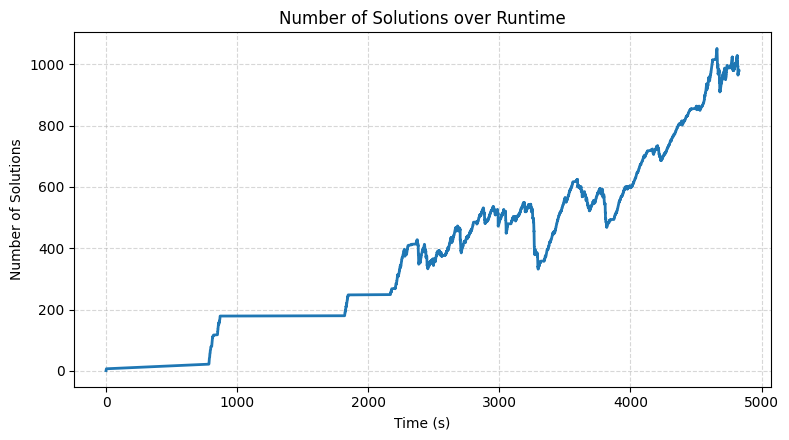

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# === CSV einlesen (Pfad anpassen) ===
df = pd.read_csv("NumberOfSolutions.csv")

# === Plot erstellen ===
plt.figure(figsize=(8, 4.5))
plt.plot(df["Time (s)"], df["Number of Solutions"], linestyle="-", linewidth=2, color="tab:blue")

# Achsen & Titel
plt.xlabel("Time (s)")
plt.ylabel("Number of Solutions")
plt.title("Number of Solutions over Runtime")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

# === Plot anzeigen ===
plt.show()

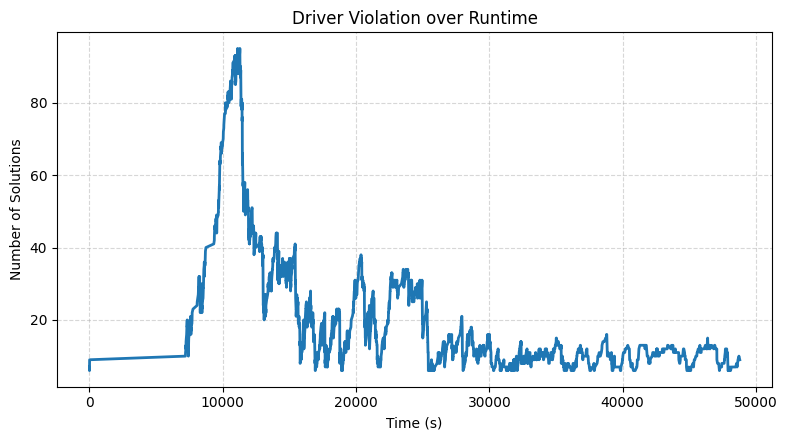

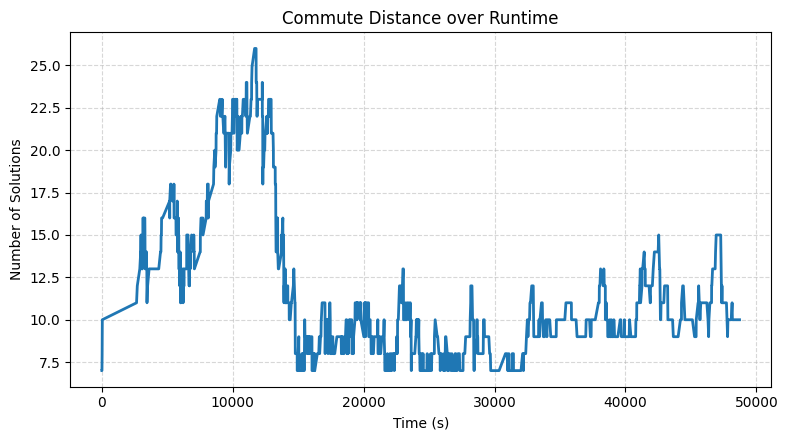

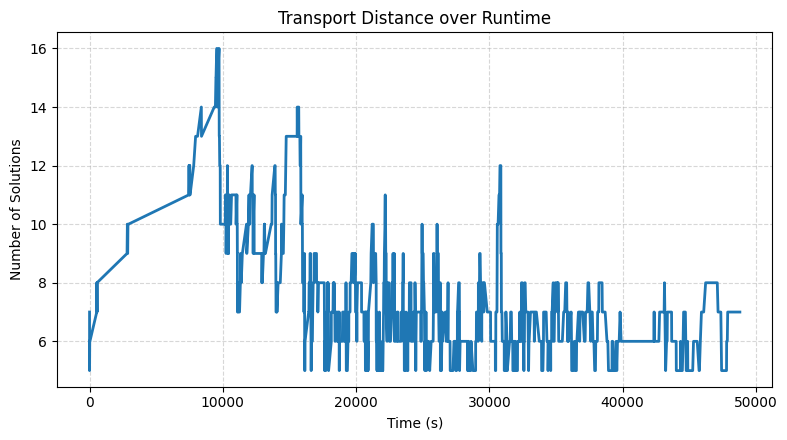

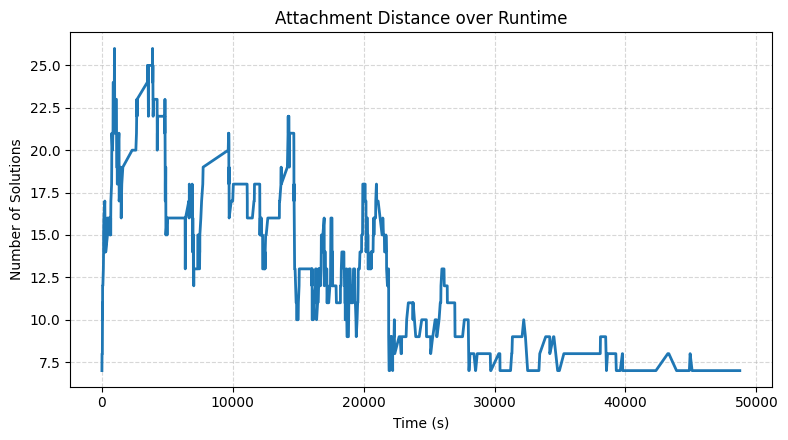

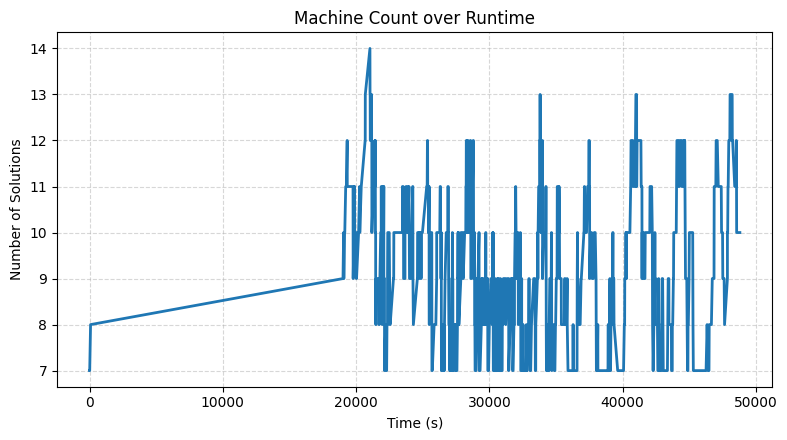

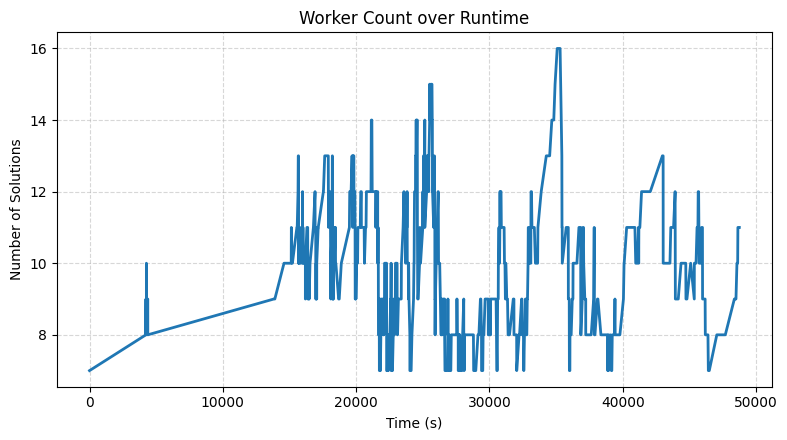

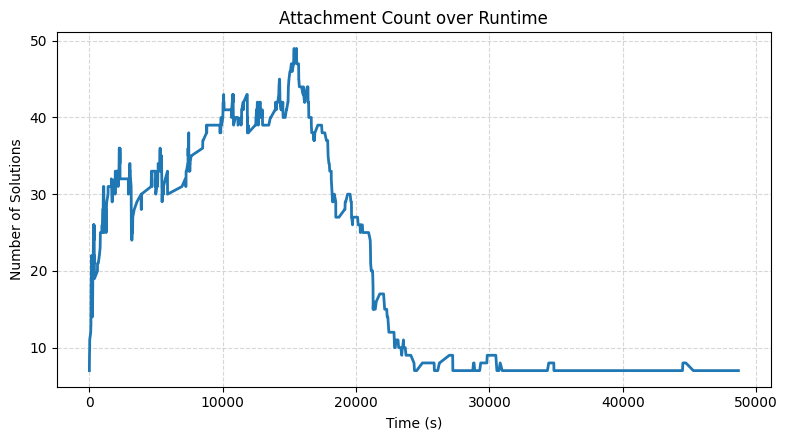

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

objectives = ["driver_violation",
              "commute_distance",
              "transport_distance",
              "attachment_distance",
              "machine_count",
              "worker_count",
              "attachment_count"]

for objective in objectives:
    # === CSV einlesen (Pfad anpassen) ===
    df = pd.read_csv(f"NumberOfSolutions_{objective}.csv")

    # === Plot erstellen ===
    plt.figure(figsize=(8, 4.5))
    plt.plot(df["Time (s)"], df["Number of Solutions"], linestyle="-", linewidth=2, color="tab:blue")

    # Achsen & Titel
    plt.xlabel("Time (s)")
    plt.ylabel("Number of Solutions")
    plt.title(f"{objective.replace('_', ' ').title()} over Runtime")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()

    # === Plot anzeigen ===
    plt.show()

In [22]:
import pandas as pd
from pathlib import Path

# === STEP 1: Ziel-Parameter ===
objectives = [
    "driver_violation", "commute_distance", "transport_distance",
    "attachment_distance", "machine_count", "worker_count", "attachment_count"
]
max_iteration = 48795

# === STEP 2: Verarbeitung aller Dateien ===
for obj in objectives:
    file_path = Path(f"NumberOfSolutions_{obj}.csv")
    df = pd.read_csv(file_path)
    df.columns = ["Time (s)", "Number of Solutions"]  # Einheitliche Spaltennamen

    # Setze den Index auf die Iteration ("Time (s)")
    df.set_index("Time (s)", inplace=True)

    # Erstelle vollständigen Index bis 48795
    full_index = pd.RangeIndex(start=0, stop=max_iteration + 1, step=1)

    # Reindex und fülle fehlende Werte mit dem letzten bekannten Wert (ffill)
    df_full = df.reindex(full_index)
    df_full.ffill(inplace=True)

    # Falls am Anfang noch NaNs sind, ersetze sie mit dem ersten bekannten Wert
    df_full.bfill(inplace=True)

    # Index zurück in Spalte umwandeln
    df_full.reset_index(inplace=True)
    df_full.columns = ["Time (s)", "Number of Solutions"]

    # Speichern der neuen Datei
    output_path = f"NumberOfSolutions_{obj}_filled.csv"
    df_full.to_csv(output_path, index=False)
    print(f"✅ Datei gespeichert: {output_path}")

✅ Datei gespeichert: NumberOfSolutions_driver_violation_filled.csv
✅ Datei gespeichert: NumberOfSolutions_commute_distance_filled.csv
✅ Datei gespeichert: NumberOfSolutions_transport_distance_filled.csv
✅ Datei gespeichert: NumberOfSolutions_attachment_distance_filled.csv
✅ Datei gespeichert: NumberOfSolutions_machine_count_filled.csv
✅ Datei gespeichert: NumberOfSolutions_worker_count_filled.csv
✅ Datei gespeichert: NumberOfSolutions_attachment_count_filled.csv


✅ Datei gespeichert als 'mapped_objective_solutions.csv'.


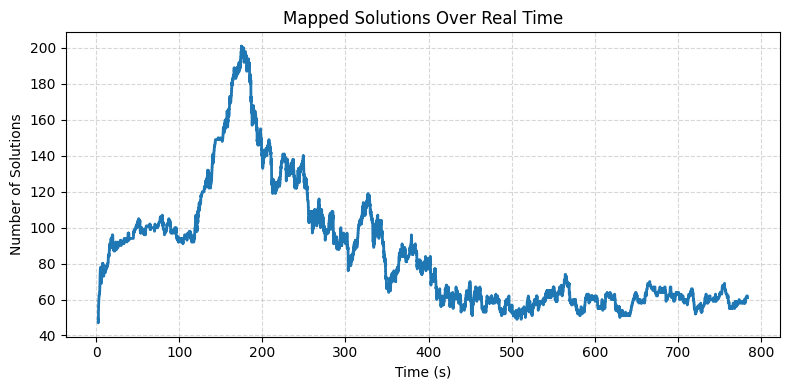

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Parameter ===
objectives = [
    "driver_violation", "commute_distance", "transport_distance",
    "attachment_distance", "machine_count", "worker_count", "attachment_count"
]

t_start = 2.6   # echte Zeit bei Iteration min
t_end = 783.8   # echte Zeit bei Iteration max

# === Schritt 1: Alle Dateien einlesen ===
all_data = []
for obj in objectives:
    df = pd.read_csv(f"NumberOfSolutions_{obj}_filled.csv")
    df.columns = ["Iteration", "Solutions"]
    all_data.append(df)

# === Schritt 2: Kombinieren & Aufsummieren nach Iteration ===
df_all = pd.concat(all_data)
df_grouped = df_all.groupby("Iteration", as_index=False)["Solutions"].sum()

# === Schritt 3: Iterationen auf Zeit umrechnen ===
iter_min = df_grouped["Iteration"].min()
iter_max = df_grouped["Iteration"].max()

df_grouped["Time (s)"] = np.interp(
    df_grouped["Iteration"],
    [iter_min, iter_max],
    [t_start, t_end]
)

# === Schritt 4: Ergebnis speichern ===
df_grouped[["Time (s)", "Solutions"]].to_csv("mapped_objective_solutions.csv", index=False)
print("✅ Datei gespeichert als 'mapped_objective_solutions.csv'.")

# === Optional: Plot anzeigen ===
plt.figure(figsize=(8, 4))
plt.plot(df_grouped["Time (s)"], df_grouped["Solutions"], color="tab:blue", lw=2)
plt.xlabel("Time (s)")
plt.ylabel("Number of Solutions")
plt.title("Mapped Solutions Over Real Time")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

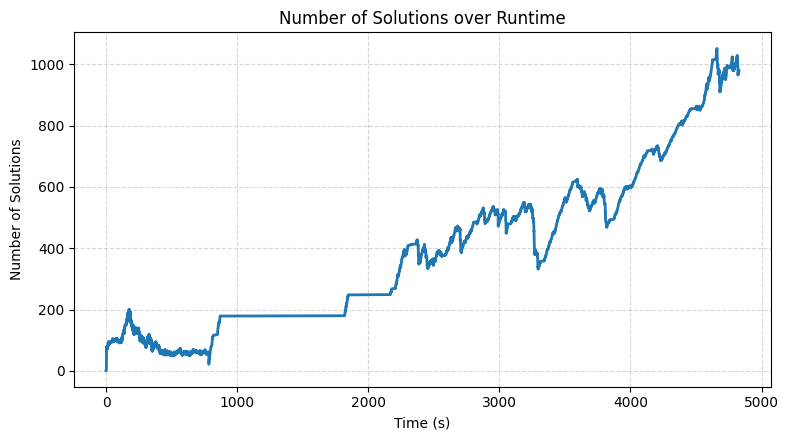

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# === CSV einlesen (Pfad anpassen) ===
df = pd.read_csv("Final_NumberOfSolutions.csv")

# === Plot erstellen ===
plt.figure(figsize=(8, 4.5))
plt.plot(df["Time (s)"], df["Number of Solutions"], linestyle="-", linewidth=2, color="tab:blue")

# Achsen & Titel
plt.xlabel("Time (s)")
plt.ylabel("Number of Solutions")
plt.title("Number of Solutions over Runtime")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

# === Plot anzeigen ===
plt.show()

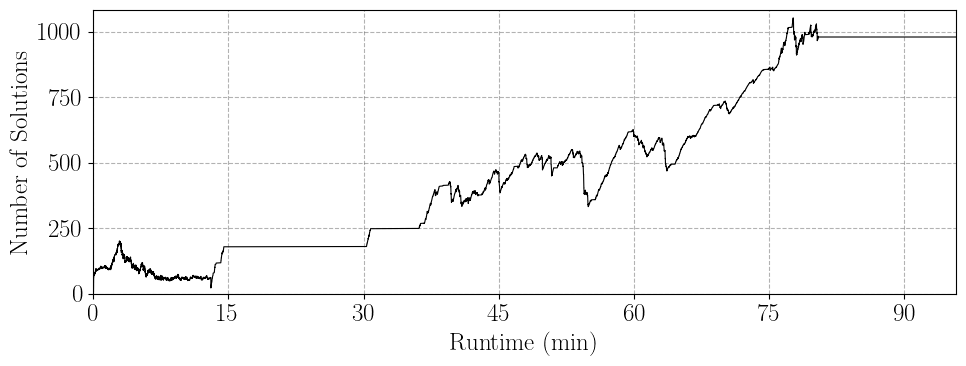

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# === LaTeX-Stil für wissenschaftliche Darstellung ===
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
})

# === Daten einlesen ===
df = pd.read_csv("Final_NumberOfSolutions.csv")
df["Time (min)"] = df["Time (s)"] / 60  # Sekunden → Minuten

# === Plot erstellen ===
plt.figure(figsize=(10, 4))
plt.grid(True, which="both", linestyle="--", color="black", alpha=0.3)

# Achsenbeschriftungen
plt.xlabel(r"{Runtime (min)}")
plt.ylabel(r"{Number of Solutions}")
plt.xlim(df["Time (min)"].min(), df["Time (min)"].max())
plt.ylim(0, df["Number of Solutions"].max() + 30)

# X-Achse: alle 15 Minuten Ticks
xticks = np.arange(0, df["Time (min)"].max()+ 9, 15)
plt.xticks(xticks)

# Kurve zeichnen
plt.plot(
    df["Time (min)"], df["Number of Solutions"],
    color="black", linewidth=0.8, linestyle="-"
)

# Plot finalisieren
plt.tight_layout()
#plt.savefig("number_of_solutions_runtime_min.pdf", bbox_inches="tight")
plt.show()